# **Healthcare Data Analysis and Predictive Modelling**

This notebook focuses on analysing hospital data to identify patterns in patient visits, doctor performance, and disease trends. The dataset consists of doctor details, patient visit records, and hospital summary statistics.

The objective is to:
- Clean and preprocess the data
- Perform exploratory data analysis (EDA)
- Prepare the dataset machine learning model (Linear Regression)
- Predict treatment costs and analyze relationships between variables

In [6]:
#Importing all the required libraries for this analysis
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
#loading of datasets
doctors = pd.read_csv("DoctorDataset.csv")
patients = pd.read_csv("PatientDataset.csv")
hospital = pd.read_csv("HospitalDataset.csv")

#Displaying datasets
print("Doctors Dataset:")
print(doctors.head())

print("\nPatients Dataset:")
print(patients.head())

print("\nHospital Dataset:")
print(hospital.head())

Doctors Dataset:
  DoctorID     Department  Rating  ConsultancyFee
0     D001  Dermatologist     4.5            5400
1     D002  Dermatologist     4.2            4800
2     D003  Dermatologist     4.3            5550
3     D004  Dermatologist     3.8            4050
4     D005  Dermatologist     3.5            3600

Patients Dataset:
  Patient_ID        Date        Day   Time Doctor_ID     Department  Age  \
0      P0001  2026-03-03    Tuesday  11:00      D015  Pulmonologist   58   
1      P0002  2026-03-11  Wednesday  13:00      D013  Pulmonologist   31   
2      P0003  2026-03-31    Tuesday  11:00      D004  Dermatologist   56   
3      P0004  2026-03-05   Thursday  11:00      D013  Pulmonologist   49   
4      P0005  2026-03-31    Tuesday   9:00      D011  Pulmonologist   27   

   Gender Outdoor_Activity         Diagnosis  Consultancy_Fee  Hospital_Fee  \
0    Male             High            Normal             4500          1500   
1  Female           Medium            Normal     

In [7]:
#Data checking/preprocessing == Checking structure, data types, and missing values.

print(patients.info())

#Check missing values
print("\nMissing values:")
print(patients.isnull().sum())

#Getting basic stats to understand the table/trend
print("\nStatistics:")
print(patients.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Patient_ID        500 non-null    object
 1   Date              500 non-null    object
 2   Day               500 non-null    object
 3   Time              500 non-null    object
 4   Doctor_ID         500 non-null    object
 5   Department        500 non-null    object
 6   Age               500 non-null    int64 
 7   Gender            500 non-null    object
 8   Outdoor_Activity  500 non-null    object
 9   Diagnosis         500 non-null    object
 10  Consultancy_Fee   500 non-null    int64 
 11  Hospital_Fee      500 non-null    int64 
 12  Total_Cost        500 non-null    int64 
dtypes: int64(4), object(9)
memory usage: 50.9+ KB
None

Missing values:
Patient_ID          0
Date                0
Day                 0
Time                0
Doctor_ID           0
Department          0


In [13]:
""" Checking for
Data Cleaning / Handling: such as
- Missing values
- Incorrect data entries (such as text instead of numbers)
- Inconsistent values / ANOMALIES

"""


#Checking of any missing row
print("Rows with missing Age:")
print(patients[patients['Age'].isnull()])

#updating new value/fixing data
patients.loc[3, 'Age'] = 30

#exmp to fix incorrect values (such as thirty)
patients.loc[patients['Age'] == 'thirty', 'Age'] = 30

#Convert column AFTER fixing
patients['Age'] = pd.to_numeric(patients['Age'])

#Verify cleaning, to countercheck
print("\nAfter manual cleaning:")
print(patients.isnull().sum())

Rows with missing Age:
Empty DataFrame
Columns: [Patient_ID, Date, Day, Time, Doctor_ID, Department, Age, Gender, Outdoor_Activity, Diagnosis, Consultancy_Fee, Hospital_Fee, Total_Cost]
Index: []

After manual cleaning:
Patient_ID          0
Date                0
Day                 0
Time                0
Doctor_ID           0
Department          0
Age                 0
Gender              0
Outdoor_Activity    0
Diagnosis           0
Consultancy_Fee     0
Hospital_Fee        0
Total_Cost          0
dtype: int64


In [85]:
"""
#Continuing Data Preprocessing : Encoding categorical variables into numeric form for machine learning

Type of Mappings used: (for noting)
- Gender: Male = 1, Female = 2
- Department: Dermatologist = 1, Ophthalmologist = 2, Pulmonologist = 3
- Diagnosis:
    Normal = 0
    Dryness/Rash = 1
    Redness/Itching = 2
    Congestion/Breathing Issues = 3
    Injury/Surgery (Outliers) = 4
- Outdoor Activity: Low = 0, Medium = 1, High = 2
"""

# Department Encoding
patients['Department'] = patients['Department'].map({
    'Dermatologist': 1,
    'Ophthalmologist': 2,
    'Pulmonologist': 3
})

# Diagnosis Encoding
patients['Diagnosis'] = patients['Diagnosis'].replace({
    'Normal': 0,
    'Dryness': 1,
    'Rash': 1,
    'Redness': 2,
    'Intense Itching': 2,
    'Nasal Congestion': 3,
    'Breathing Issues': 3,
    'Injury/Surgery': 4,
    'Injury/Infection': 4
})

# Outdoor Activity Encoding
patients['Outdoor_Activity'] = patients['Outdoor_Activity'].map({
    'Low': 0,
    'Medium': 1,
    'High': 2
})

# Gender Encoding
patients['Gender'] = patients['Gender'].map({
    'Male': 1,
    'Female': 2
})

# Check results
print(patients.head())

  Patient_ID       Date        Day   Time Doctor_ID  Department  Age  Gender  \
0      P0001 2026-03-03    Tuesday  11:00      D015         NaN   58     NaN   
1      P0002 2026-03-11  Wednesday  13:00      D013         NaN   31     NaN   
2      P0003 2026-03-31    Tuesday  11:00      D004         NaN   56     NaN   
3      P0004 2026-03-05   Thursday  11:00      D013         NaN   30     NaN   
4      P0005 2026-03-31    Tuesday   9:00      D011         NaN   27     NaN   

   Outdoor_Activity Diagnosis  Consultancy_Fee  Hospital_Fee  Total_Cost  \
0               NaN         6             4500          1500        6000   
1               NaN         6             3600          1000        4600   
2               NaN         7             4050          2000        6050   
3               NaN         6             3600          1500        5100   
4               NaN         0             5100          2000        7100   

   Week  DayNum  AdjustedCost  
0     1       2   6149.014246 

**Performing Exploratory Data Analysis (EDA)**

EDA is performed to understand trends, relationships, and patterns in the dataset, which in turn helps to select certain features for ML


In [89]:
'''
Now working with the updated csv file!!!
'''

#loading the updated datasets.
doctors = pd.read_csv("DoctorDataset_updated.csv")
patients = pd.read_csv("PatientDataset_updated.csv")
hospital = pd.read_csv("HospitalDataset_updated.csv")

#Displaying datasets
print("Doctors Dataset:")
print(doctors.head())

print("\nPatients Dataset:")
print(patients.head())

print("\nHospital Dataset:")
print(hospital.head())

Doctors Dataset:
  DoctorID  Department  Rating  ConsultancyFee
0     D001           1     4.5            5400
1     D002           1     4.2            4800
2     D003           1     4.3            5550
3     D004           1     3.8            4050
4     D005           1     3.5            3600

Patients Dataset:
  Patient_ID       Date  Day   Time Doctor_ID  Department  Age  Gender  \
0      P0001   3/3/2026    2  11:00      D015           3   58       1   
1      P0002  3/11/2026    3  13:00      D013           3   31       2   
2      P0003  3/31/2026    2  11:00      D004           1   56       1   
3      P0004   3/5/2026    4  11:00      D013           3   49       2   
4      P0005  3/31/2026    2  09:00      D011           3   27       1   

   Outdoor_Activity  Diagnosis  Consultancy_Fee  Hospital_Fee  Total_Cost  
0                 2          0             4500          1500        6000  
1                 1          0             3600          1000        4600  
2        

Department
2    171
1    165
3    164
Name: count, dtype: int64


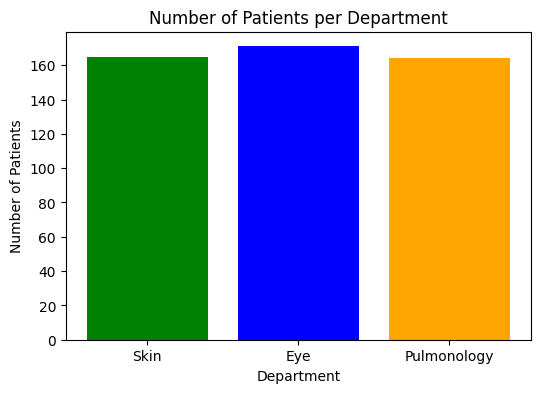

In [90]:
# print(patients['Department'].value_counts())
# print(patients.columns)

#count number of patients per department
dept_counts = patients['Department'].value_counts()

print(dept_counts)#counter checking values

#ploting graph
plt.figure(figsize=(6,4))

plt.bar(dept_counts.index, dept_counts.values, color=['blue','green','orange'])

plt.title("Number of Patients per Department")
plt.xlabel("Department")
plt.ylabel("Number of Patients")

#Replace number with name of each department
plt.xticks([1,2,3], ['Skin', 'Eye', 'Pulmonology']) #for easy understanding

plt.show()

/tmp/ipykernel_3206/3780084234.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Day', data=patients, palette='cool')


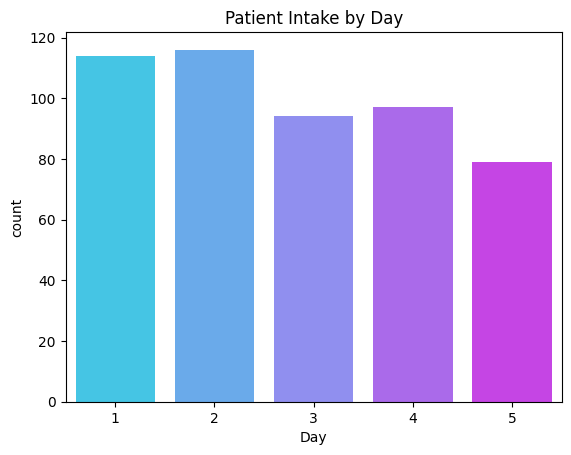

In [91]:
#Showing average of patient intake by day
sns.countplot(x='Day', data=patients, palette='cool')

plt.title("Patient Intake by Day")
plt.show()

/tmp/ipykernel_3206/3215847547.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Week', data=patients, palette='cool')


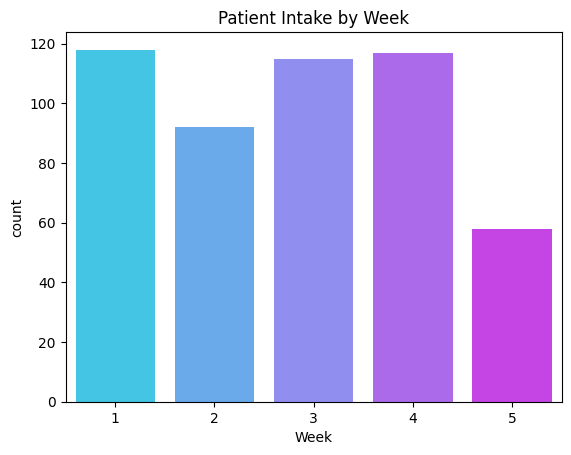

In [20]:
#Showing weekly trend of patient

patients['Date'] = pd.to_datetime(patients['Date'])
patients['Week'] = patients['Date'].dt.day // 7 + 1

sns.countplot(x='Week', data=patients, palette='cool')
plt.title("Patient Intake by Week")
plt.show()

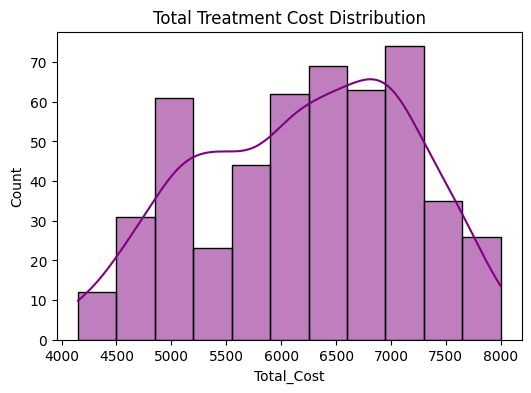

In [22]:
#Treatment Cost (Hospital + Consultancy charges) distribution

plt.figure(figsize=(6,4))
sns.histplot(patients['Total_Cost'], kde=True, color='purple')
plt.title("Total Treatment Cost Distribution")
plt.show()

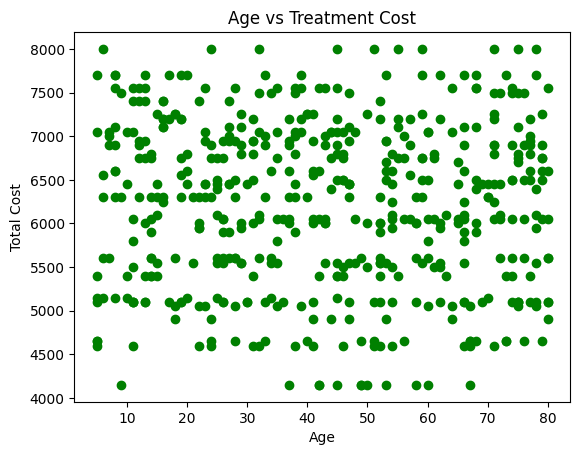

In [24]:
#Age VS Cost scatter graph

plt.scatter(patients['Age'], patients['Total_Cost'], color='green')
plt.xlabel("Age")
plt.ylabel("Total Cost")
plt.title("Age vs Treatment Cost")
plt.show()

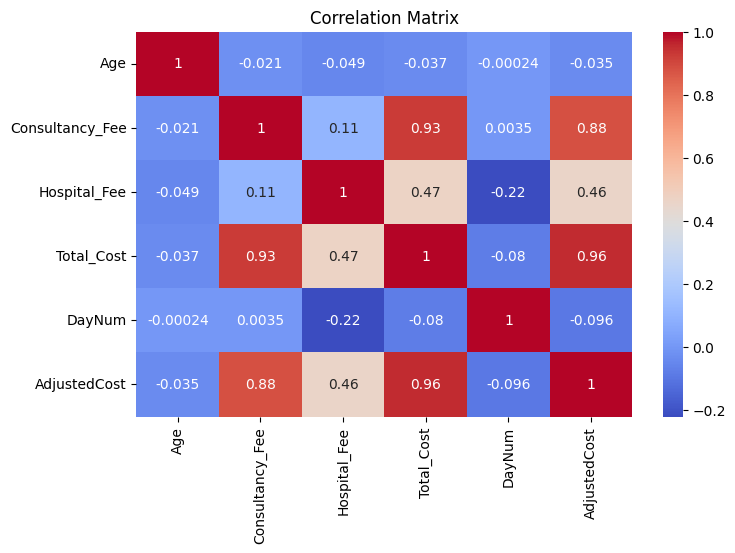

In [87]:
#Selecting only numeric columns
numeric_data = patients.select_dtypes(include=['int64', 'float64'])

corr = numeric_data.corr()

#heatmapPloting
plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

# Model **Training**

In [54]:
np.random.seed(42)

noise = np.random.normal(0, 300, size=len(patients))  # std deviation = 300

#new target variable (to predict later on)
patients['AdjustedCost'] = patients['Total_Cost'] + noise

#no negative values to avoid anomalous result
patients['AdjustedCost'] = patients['AdjustedCost'].clip(lower=0)

In [56]:
X = patients[['Age', 'Consultancy_Fee', 'Hospital_Fee', 'Department']]
y = patients['AdjustedCost']

In [57]:
X = pd.get_dummies(X, columns=['Department'], drop_first=True)

In [67]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Model training successful")

Model training successful


In [59]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [66]:
predictions = model.predict(X_test)
print("Sample Predictions:")
print(predictions[:5])

Sample Predictions:
[6751.08819892 5561.91719195 7564.57757995 6080.33068542 7200.4000627 ]


In [100]:
#EVALUATION
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("MAE:", round(mae))
print("RMSE:", round(rmse))
print("R² Score:", round(r2, 2))

MAE: 221
RMSE: 296
R² Score: 0.91


In [71]:
#PREDICTION of treatment cost
# print(X.columns)

new_data = pd.DataFrame({
    'Age': [40],
    'Consultancy_Fee': [5000],
    'Hospital_Fee': [2000]
})

predicted_cost = model.predict(new_data)

print("Predicted Treatment Cost:", round(predicted_cost[0]))

Predicted Treatment Cost: 7016


# **Linear Regression Model**


In [51]:
#Comparing total cost with different factors for linear rgr
X = patients[['Age', 'Consultancy_Fee', 'Hospital_Fee']]
y = patients['Total_Cost']

#The train-test split - (20-80
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

#importing model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

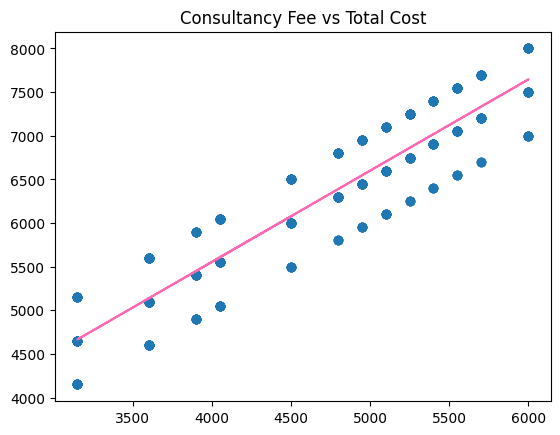

In [98]:
#attempt at simple regression
x = patients['Consultancy_Fee']
y = patients['Total_Cost']

slope, intercept, r, p, std_err = stats.linregress(x, y)

def myfunc(x):
    return slope*x + intercept

mymodel = list(map(myfunc, x))

plt.scatter(x, y)
plt.plot(x, mymodel, color='hotpink')
plt.title("Consultancy Fee vs Total Cost")
plt.show()

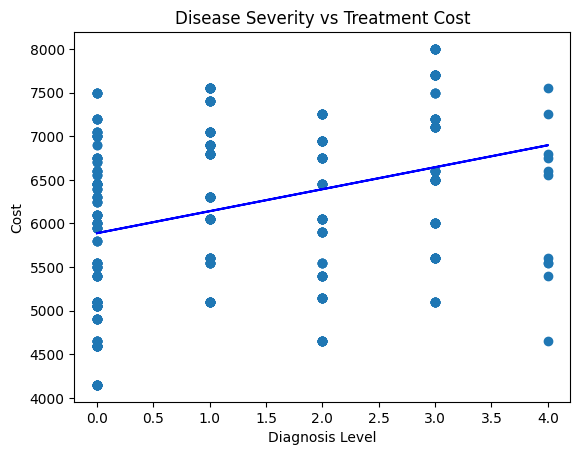

In [99]:
x = patients['Diagnosis']
y = patients['Total_Cost']

slope, intercept, r, p, std_err = stats.linregress(x, y)

def model_func(x):
    return slope * x + intercept

model_line = list(map(model_func, x))

plt.scatter(x, y)
plt.plot(x, model_line, color='blue')
plt.title("Disease Severity vs Treatment Cost")
plt.xlabel("Diagnosis Level")
plt.ylabel("Cost")
plt.show()

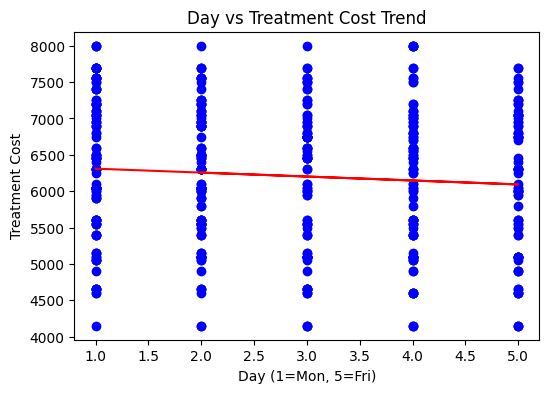

In [94]:
# Linear regression
x = patients['Day']
y = patients['Total_Cost']

slope, intercept, r, p, std_err = stats.linregress(x, y)

def trend_line(x):
    return slope * x + intercept

model_line = list(map(trend_line, x))

# Plot
plt.figure(figsize=(6,4))
plt.scatter(x, y, color='blue')
plt.plot(x, model_line, color='red')

plt.title("Day vs Treatment Cost Trend")
plt.xlabel("Day (1=Mon, 5=Fri)")
plt.ylabel("Treatment Cost")

plt.show()

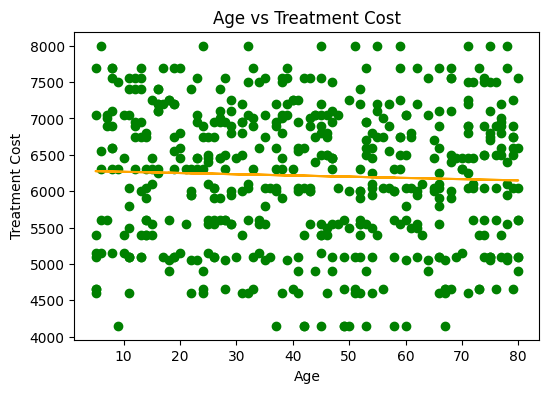

In [95]:
x = patients['Age']
y = patients['Total_Cost']

slope, intercept, r, p, std_err = stats.linregress(x, y)

def age_model(x):
    return slope * x + intercept

model_line = list(map(age_model, x))

plt.figure(figsize=(6,4))
plt.scatter(x, y, color='green')
plt.plot(x, model_line, color='orange')

plt.title("Age vs Treatment Cost")
plt.xlabel("Age")
plt.ylabel("Treatment Cost")

plt.show()

In [97]:
# PREDICTION OF treatment cost.
new_data = pd.DataFrame({
    'Age': [50],
    'Consultancy_Fee': [5500],
    'Hospital_Fee': [2000],
    'Department': [3],#which is skin dept
    'Diagnosis': [3] #breathing issue
})

new_data = new_data[X.columns]

predicted_cost = model.predict(new_data)

print("Predicted Treatment Cost:", round(predicted_cost[0]))


Predicted Treatment Cost: 7519


In [49]:
#PREDICTION of patients next week!!
#Count patients per day
intake = patients['Day'].value_counts()

print("Patient intake per day:")
print(intake)

#next week's simple mean.
predicted_intake = intake.mean()

print("Predicted intake next week:", predicted_intake)

Patient intake per day:
Day
Tuesday      116
Monday       114
Thursday      97
Wednesday     94
Friday        79
Name: count, dtype: int64
Predicted intake next week: 100.0
